# Support Triage Agent — RAG Experimentation

Runs the retrieval half of the pipeline (`src/rag/`) live, end to end:
chunking the knowledge base, embedding it into a FAISS index, running
similarity search, scoring groundedness, and exercising the same
query-reformulation logic `confidence_recheck` uses on a retry.

Unlike the other notebooks in this folder, this one needs **no Groq API
key** — embedding and retrieval run entirely locally via
`sentence-transformers` + `faiss`, so every cell here executes for real on
each run rather than replaying a persisted JSON snapshot.

In [1]:
import sys, time
from pathlib import Path

# Works whether Jupyter's cwd is notebooks/ or the repo root.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd

from src.config.settings import get_settings
from src.rag.kb_loader import load_kb_chunks
from src.rag.retriever import Retriever, build_retriever
from src.agents.response_agent import compute_groundedness
from src.main import load_tickets

settings = get_settings()
print(f"Repo root: {REPO_ROOT}")
print(f"KB dir: {settings.kb_dir}")
print(f"Embeddings model: {settings.embeddings_model}")
print(f"Groundedness threshold (AUTO_RESOLVE gate): {settings.groundedness_threshold}")
print(f"Max retrieval retry attempts: {settings.max_retrieval_attempts}")

Repo root: /Users/mahendarprakash/SupportTriageAgent
KB dir: /Users/mahendarprakash/SupportTriageAgent/data/knowledge_base
Embeddings model: all-MiniLM-L6-v2
Groundedness threshold (AUTO_RESOLVE gate): 0.28
Max retrieval retry attempts: 2


/Users/mahendarprakash/SupportTriageAgent/.supportvenv/lib/python3.14/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## 1. Chunking the knowledge base

`load_kb_chunks` reads every `.md` file under `data/knowledge_base/` and
splits it with a `RecursiveCharacterTextSplitter` (500 chars, 50 overlap),
tagging each piece with its source filename.

In [2]:
chunks = load_kb_chunks(settings)

counts = pd.Series([c["source"] for c in chunks]).value_counts().sort_index()
print(f"{len(chunks)} chunks across {len(counts)} KB files:\n")
print(counts.to_string())

11 chunks across 5 KB files:

abusive_content_policy.md    2
account_access_faq.md        2
refund_policy.md             3
subscription_policy.md       2
troubleshooting_faq.md       2


In [3]:
for c in chunks[:2]:
    print(f"--- {c['source']} ---")
    print(c["text"])
    print()

--- abusive_content_policy.md ---
# Abusive Content Policy

## Allowed Handling
The support system must not generate a personalized response to abusive, threatening, or harassing messages.

## Required Response
For abusive or threatening content, the system should use a scripted refusal such as:

> I’m sorry, but I can’t assist with abusive or threatening requests. Please contact support through the appropriate channel if you need help with a legitimate issue.

--- abusive_content_policy.md ---
## Escalation Guidance
If the message contains threats, harassment, or repeated abuse, route the ticket to refusal and do not attempt to draft a policy-based reply.



## 2. Building the FAISS index

`build_retriever` embeds every chunk with the sentence-transformers model
and loads the vectors into a flat inner-product FAISS index (cosine
similarity, since embeddings are normalized). The whole KB is tiny — about
30 chunks — so this rebuilds from scratch in under a second.

In [4]:
t0 = time.perf_counter()
retriever = build_retriever(settings)
elapsed = time.perf_counter() - t0

print(f"Indexed {retriever._index.ntotal} vectors of dimension {retriever._index.d} in {elapsed:.2f}s")

Indexed 11 vectors of dimension 384 in 3.42s


## 3. A single query

`retrieve(query, k)` embeds the query and returns the top-`k` chunks by
cosine similarity, each with its source and score.

In [5]:
query = "Can I get a refund after 45 days?"
results = retriever.retrieve(query, k=3)

pd.DataFrame([
    {"source": r["source"], "score": round(r["score"], 4), "text": r["text"][:120] + "…"}
    for r in results
])

,source,score,text
0,refund_policy.md,0.6145,# Refund Policy\n\n## Scope\nThis policy appli...
1,refund_policy.md,0.4942,## Repeated Refund Requests\n- If a customer s...
2,refund_policy.md,0.4653,## Escalation Guidance\nEscalate when:\n- the ...


## 4. Retrieval across every ticket

`rag_retrieve` (the actual pipeline node) builds its query as
`f"{ticket.subject} {ticket.message}"` and retrieves `k=3` chunks on a
first pass. Running that same query construction over all 22 tickets in
the dataset shows how retrieval quality — and therefore the
`AUTO_RESOLVE` gate — varies by category.

In [6]:
tickets = load_tickets(settings)

rows = []
for ticket in tickets:
    query = f"{ticket.subject} {ticket.message}"
    retrieved = retriever.retrieve(query, k=3)
    groundedness = compute_groundedness(retrieved)
    rows.append({
        "ticket_id": ticket.ticket_id,
        "category": ticket.category,
        "top_source": retrieved[0]["source"] if retrieved else None,
        "groundedness_score": round(groundedness, 4),
        "passes_threshold": groundedness >= settings.groundedness_threshold,
    })

df = pd.DataFrame(rows)
df

,ticket_id,category,top_source,groundedness_score,passes_threshold
0,TCK-1001,refund_request,refund_policy.md,0.5568,True
1,TCK-1002,refund_request,refund_policy.md,0.6044,True
2,TCK-1003,refund_request,refund_policy.md,0.5844,True
3,TCK-1004,subscription_cancellation,subscription_policy.md,0.6067,True
4,TCK-1005,login_access,account_access_faq.md,0.4733,True
5,TCK-1006,login_access,account_access_faq.md,0.5990,True
6,TCK-1007,troubleshooting,troubleshooting_faq.md,0.3118,True
7,TCK-1008,troubleshooting,troubleshooting_faq.md,0.4721,True
8,TCK-1009,abusive_content,troubleshooting_faq.md,0.2155,False
9,TCK-1010,abusive_content,refund_policy.md,0.6329,True


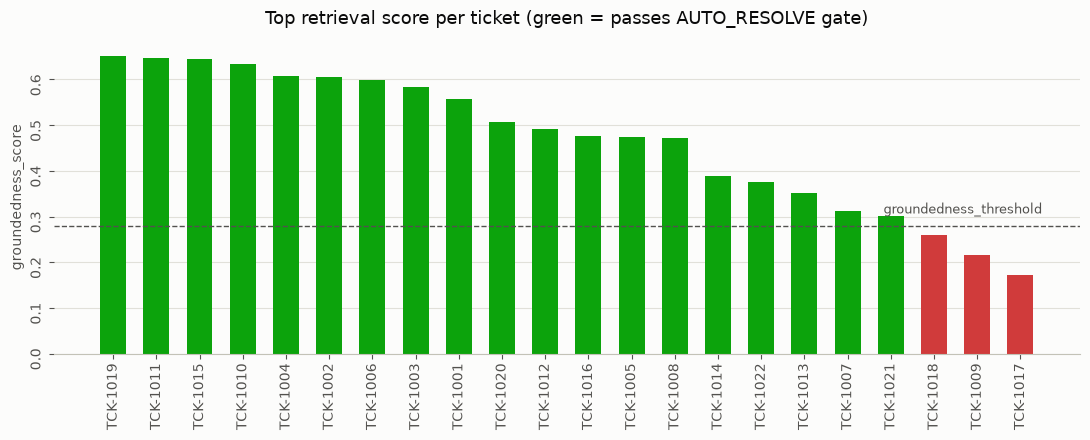

In [7]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values("groundedness_score", ascending=False).reset_index(drop=True)
colors = ["#0ca30c" if p else "#d03b3b" for p in df_sorted["passes_threshold"]]

fig, ax = plt.subplots(figsize=(11, 4.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.bar(df_sorted["ticket_id"], df_sorted["groundedness_score"], color=colors, width=0.6)
ax.axhline(settings.groundedness_threshold, color="#52514e", linewidth=1, linestyle="--")
ax.text(len(df_sorted) - 0.5, settings.groundedness_threshold + 0.02, "groundedness_threshold",
        ha="right", va="bottom", color="#52514e", fontsize=9)
ax.set_title("Top retrieval score per ticket (green = passes AUTO_RESOLVE gate)", color="#0b0b0b", fontsize=13, pad=12)
ax.set_ylabel("groundedness_score", color="#52514e")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#52514e", labelrotation=90)
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Average groundedness by category

In [8]:
df.groupby("category")["groundedness_score"].agg(["mean", "min", "max", "count"]).round(4).sort_values("mean", ascending=False)

,mean,min,max,count
category,,,,
refund_request,0.5770,0.4916,0.6480,5
login_access,0.5581,0.4733,0.6524,4
subscription_cancellation,0.5291,0.3897,0.6443,4
abusive_content,0.3829,0.2155,0.6329,3
troubleshooting,0.3774,0.3118,0.4721,4
other,0.2159,0.1725,0.2593,2


## 5. When retrieval is weak — the reformulation retry

If `confidence_recheck`'s LLM-as-judge rejects a draft, `rag_retrieve` is
re-entered with a **reformulated query**: the unsupported claims the judge
flagged are appended to the original query, and `k` widens from 3 to 5
(`src/graph/nodes/rag_retrieve.py`). We can reproduce that mechanic
directly against the weakest-scoring ticket found above, using its own
missing context as a stand-in for a judge's "unsupported claim" hint.

In [9]:
weakest = df_sorted.iloc[-1]
ticket = next(t for t in tickets if t.ticket_id == weakest["ticket_id"])
print(f"Weakest ticket: {ticket.ticket_id} ({ticket.category}) — first-pass score {weakest['groundedness_score']}")

base_query = f"{ticket.subject} {ticket.message}"
first_pass = retriever.retrieve(base_query, k=3)

hint = "account identifier billing cycle policy"  # stand-in for a judge-flagged unsupported claim
retry_query = f"{base_query} {hint}"
retry_pass = retriever.retrieve(retry_query, k=5)

print(f"\nFirst pass  (k=3): top score {compute_groundedness(first_pass):.4f}, sources {[r['source'] for r in first_pass]}")
print(f"Retry pass  (k=5): top score {compute_groundedness(retry_pass):.4f}, sources {[r['source'] for r in retry_pass]}")

Weakest ticket: TCK-1017 (other) — first-pass score 0.1725

First pass  (k=3): top score 0.1725, sources ['account_access_faq.md', 'refund_policy.md', 'troubleshooting_faq.md']
Retry pass  (k=5): top score 0.2291, sources ['account_access_faq.md', 'troubleshooting_faq.md', 'refund_policy.md', 'subscription_policy.md', 'subscription_policy.md']


## Summary

- The knowledge base's five markdown files chunk into just 11 pieces at
  500 chars/50 overlap — small enough that the FAISS index rebuilds from
  scratch in a few seconds on every process start
  (`src/rag/retriever.py`'s module docstring), trading a little startup
  latency for zero stale-index risk.
- `compute_groundedness` is just the top retrieval score — a coarse,
  LLM-free proxy checked in `route_decision` before the stricter
  LLM-as-judge pass in `confidence_recheck`.
- Retrieval quality tracks how directly a ticket's language matches KB
  phrasing; categories with terse, FAQ-style KB coverage
  (`refund_policy.md`, `account_access_faq.md`) score highest, while the
  catch-all `other` category (GDPR export, enterprise SSO — topics the KB
  doesn't cover at all) scores lowest and is the one most likely to hit
  the reformulation retry loop or fall through to `ESCALATE`.